# Image Recognition Project — Model 1: Custom CNN
**Classes:** Fumo · Chocopuni 

This is the baseline model — a small convolutional neural network trained **from scratch**
on our own dataset. It serves as a reference point to measure how much pretrained models
(Models 2 and 3) improve over a naive approach.

**Expected outcome:** Moderate accuracy with visible overfitting, since we have very few
images and no pretrained weights to build on.

# Introduction and description of the dataset


This project tackles a niche but visually interesting problem: distinguishing between
two types of Japanese plush toys based on the *Touhou Project* franchise —
**Fumo** and **Chocopuni**. Both represent the same characters, but differ
significantly in style, shape, and manufacturer.

| | Fumo (FumoFumo) | Chocopuni (Chokopuni) |
|---|---|---|
| **Manufacturer** | Gift (official) | Good Smile Company |
| **Style** | Classic, slightly angular, "mofumofu" | Round, chibi, soft "puni" shape |
| **Size** | ~20–25 cm (seated) | Smaller, more compact |
| **Origin** | Touhou Project (general) | Touhou LostWord (game) |
| **Face** | Flat face, embroidered eyes | Softer features, printed eyes |

Despite belonging to the same franchise, the two types have distinct silhouettes,
proportions, and textures — making this a realistic fine-grained visual classification task.


### Dataset


The Fumo and Chocopuni datasets consist of approximately 90% pictures taken by myself and friends.
The remaining images were scraped from the internet and used primarily as test data —
the goal being to verify that the model can recognize plushies it has never seen before,
not just the ones it was trained on. This gives a much more honest measure of real-world performance.

📁 **Dataset:** [Link to dataset](https://drive.google.com/drive/folders/1gp_d7FjI8-9Uuu579UwrCWxPdw3DeMX8) 

The dataset is split into three subsets:
- **Train (70%)** — used for model training with augmentation
- **Validation (15%)** — used for early stopping and hyperparameter decisions
- **Test (15%)** — held out entirely, only used for final evaluation

## 1. Imports

This model uses **Keras with a PyTorch backend** (`KERAS_BACKEND=torch`).
Keras provides a clean high-level API (`.compile()`, `.fit()`) while PyTorch handles
the actual tensor operations and GPU communication underneath.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import torch
import keras
from keras import layers
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"Keras version:   {keras.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Compute capability: {torch.cuda.get_device_capability(0)}")
else:
    print("WARNING: GPU not found — training will be slow on CPU!")

PyTorch version: 2.6.0+cu124
Keras version:   3.13.2
CUDA available:  True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Compute capability: (8, 9)


## 2. Configuration

| Parameter | Value | Notes |
|-----------|-------|-------|
| `IMG_SIZE` | 224 | Standard input size for CNNs |
| `BATCH_SIZE` | 16 | Small batch fits our small dataset |
| `EPOCHS` | 20 | Max epochs — early stopping will likely trigger before this |
| `NUM_WORKERS` | 8 | Parallel data loading; lower to 0 if DataLoader errors appear |

In [2]:
IMG_SIZE    = 224
BATCH_SIZE  = 16
EPOCHS      = 20
NUM_WORKERS = 8   # Lower to 0 if you get DataLoader errors

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

## 3. Data Transforms & Loading

Augmentation is applied **in the DataLoader**, not inside the model.

### Why augment?
With a small dataset, augmentation artificially expands variety so the model
doesn't memorize exact training images. Each epoch, the model sees slightly
different versions of the same images.

| Transform | Applied to | Purpose |
|-----------|-----------|---------|
| `Resize` | Train + Val/Test | Standardize input dimensions |
| `RandomHorizontalFlip` | Train only | Plushies look the same mirrored |
| `RandomRotation(15)` | Train only | Handles tilted photos |
| `ColorJitter` | Train only | Simulates different lighting |
| `Normalize` | Train + Val/Test | Required for stable training |

> **Important:** Augmentation is applied **only to training data**.
> Validation and test data use only resize + normalize so we evaluate
> on clean, unmodified images.

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ImageFolder expects: data/train/class_name/image.jpg
train_dataset = datasets.ImageFolder("./data/train",      transform=train_transform)
val_dataset   = datasets.ImageFolder("./data/validation", transform=val_test_transform)
test_dataset  = datasets.ImageFolder("./data/test",       transform=val_test_transform)

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"Found {NUM_CLASSES} classes: {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=NUM_WORKERS > 0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=NUM_WORKERS > 0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

Found 2 classes: ['chocopuni', 'fumo']
Train: 181 | Val: 100 | Test: 41


## 4. Visual Data Check

A sanity check to confirm images and labels are loading correctly.

After normalization, pixel values are no longer in the [0, 1] range — they've been
shifted by the ImageNet mean and scaled by the standard deviation. This makes raw tensors
look washed out or oddly colored when displayed directly.

`denormalize()` reverses this operation so images look natural again.

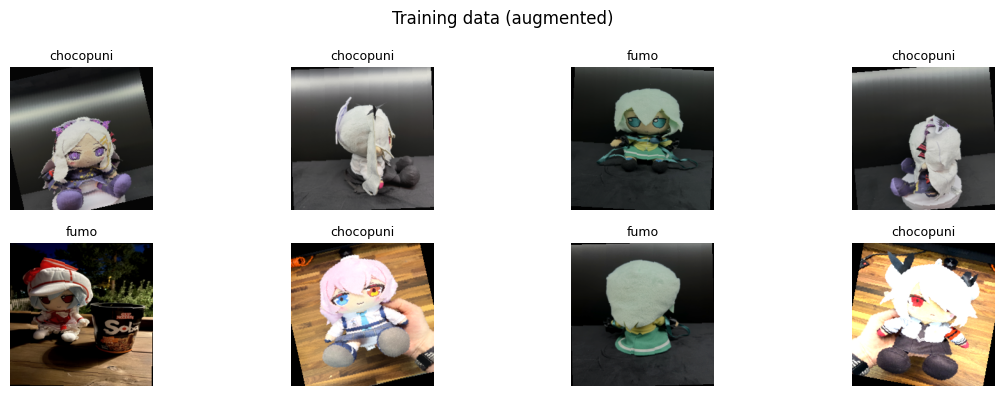

In [4]:
def denormalize(tensor):
    """Reverse ImageNet normalization for display purposes."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 4))
for i in range(min(8, len(images))):
    ax = plt.subplot(2, 4, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(CLASS_NAMES[labels[i].item()], fontsize=9)
    plt.axis("off")
plt.suptitle("Training data (augmented)", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Model Architecture — Custom CNN

A simple 3-block convolutional network built with Keras.

**Why growing filter counts (32 → 64 → 128)?**
Early layers detect simple patterns (edges, colors). Deeper layers combine
those into complex shapes. More filters = more patterns detectable at that level.

**Why using GELU instead of ReLU?**
GELU (Gaussian Error Linear Unit) is smoother than ReLU and tends to perform
slightly better in practice on image tasks.


GELU (Gaussian Error Linear Unit) is defined as:

$$\text{GELU}(x) = x \cdot \Phi(x)$$

where $\Phi(x)$ is the cumulative distribution function of the standard normal distribution.

In practice, this means:
- Unlike ReLU which hard-cuts negative values to zero, GELU **smoothly gates** them —
  small negative values are suppressed but not entirely zeroed out
- This smooth non-linearity tends to produce **better gradient flow** during backpropagation
- On small datasets it often converges slightly faster than ReLU due to smoother loss landscape




**Why Dropout(0.5)?**
With a small dataset, the fully connected layer is the most likely place to overfit.
Dropout randomly zeroes 50% of activations during training, forcing the network
to learn redundant representations.

> ⚠️ **Known limitation:** Keras with a PyTorch backend expects images in `(H, W, C)` format,
> but torchvision delivers `(C, H, W)`. The `Permute` layer handles this conversion automatically,
> but it caused kernel crashes in earlier experiments — this is one reason Model 2 switches to pure PyTorch.

In [5]:
def build_cnn(num_classes):
    inputs = keras.Input(shape=(3, IMG_SIZE, IMG_SIZE))

    # torchvision gives (C, H, W) — Keras expects (H, W, C)
    x = layers.Permute((2, 3, 1))(inputs)

    # Conv block 1 — detect low-level features (edges, colors)
    x = layers.Conv2D(32,  kernel_size=3, activation="gelu", padding="same")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    # Conv block 2 — detect mid-level features (textures, patterns)
    x = layers.Conv2D(64,  kernel_size=3, activation="gelu", padding="same")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    # Conv block 3 — detect high-level features (shapes, parts)
    x = layers.Conv2D(128, kernel_size=3, activation="gelu", padding="same")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    # Classifier head
    x = layers.Flatten()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs=inputs, outputs=outputs)


model = build_cnn(NUM_CLASSES)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 3, 224, 224)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ permute (Permute)                    │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2)                   │         200,706 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 293,954 (1.12 MB)

 Trainable params: 293,954 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Training

### Optimizer: AdamW
AdamW is Adam with proper weight decay (L2 regularization decoupled from the gradient update).
It generally outperforms plain SGD on small datasets and converges faster.

### Loss: Sparse Categorical Crossentropy
Used for multi-class classification when labels are integers (not one-hot encoded).
It measures how far the predicted probability distribution is from the true label.

### Callbacks

| Callback | Purpose |
|----------|---------|
| `ModelCheckpoint` | Saves the model weights whenever `val_loss` improves |
| `EarlyStopping` | Stops training if `val_loss` hasn't improved for 5 epochs, then restores the best weights |

Early stopping prevents wasted computation and overfitting — once the model stops
improving on validation data, continuing to train only hurts generalization.

In [6]:
model.compile(
    optimizer="adamw",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="models/CNN/best_custom_cnn.keras",
        save_best_only=True,
        monitor="val_loss",
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

history = model.fit(
    train_loader,
    epochs=EPOCHS,
    validation_data=val_loader,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.6566 - loss: 0.6874
Epoch 1: val_loss improved from None to 0.60101, saving model to models/CNN/best_custom_cnn.keras

Epoch 1: finished saving model to models/CNN/best_custom_cnn.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 74s 5s/step - accuracy: 0.6630 - loss: 0.8300 - val_accuracy: 0.6600 - val_loss: 0.6010
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6486 - loss: 0.6325
Epoch 2: val_loss did not improve from 0.60101
12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.6740 - loss: 0.5999 - val_accuracy: 0.6500 - val_loss: 0.8472
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.7060 - loss: 0.5643
Epoch 3: val_loss did not improve from 0.60101
12/12 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.7680 - loss: 0.4493 - val_accuracy: 0.7000 - val_loss: 0.7357
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.8978 - loss: 0.2827
Epoch 4: val_loss did not improve from 0.60101
12/12 ━

## 7. Learning Curves

### What to look for:
- **Good fit:** Training and validation curves track each other closely
- **Overfitting:** Training accuracy keeps climbing while validation plateaus or drops — expected here given the small dataset
- **Underfitting:** Both curves are low and flat — model is too simple or LR too low
- **Early stopping trigger:** The validation curve will flatten and the run ends before `EPOCHS` is reached

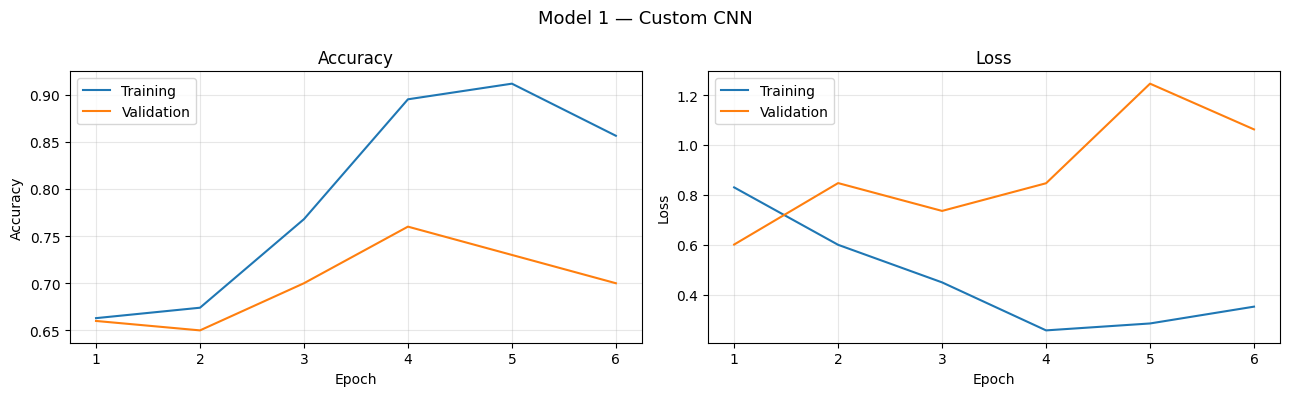

In [7]:
def plot_history(history, title="Model 1 — Custom CNN"):
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs   = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=13)

    ax1.plot(epochs, acc,     label="Training")
    ax1.plot(epochs, val_acc, label="Validation")
    ax1.set_title("Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, loss,     label="Training")
    ax2.plot(epochs, val_loss, label="Validation")
    ax2.set_title("Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history)

## 8. Test Evaluation — Best Saved Model

We reload the best checkpoint saved by `ModelCheckpoint` and evaluate it on the
held-out test set.

In [8]:
test_model = keras.models.load_model("models/CNN/best_custom_cnn.keras")

print(f"Found {len(test_dataset)} test images. Starting evaluation...")
test_loss, test_acc = test_model.evaluate(test_loader, verbose=1)

print(f"\n=== Test Results — Model 1 ===")
print(f"Accuracy : {test_acc:.3f}  ({test_acc * 100:.1f} %)")
print(f"Loss     : {test_loss:.3f}")

Found 41 test images. Starting evaluation...
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6098 - loss: 0.6711

=== Test Results — Model 1 ===
Accuracy : 0.610  (61.0 %)
Loss     : 0.671


## 9. Prediction Grid

Visualizes model predictions on a sample from the test set.
- **Green title** = correct prediction
- **Red title** = wrong prediction


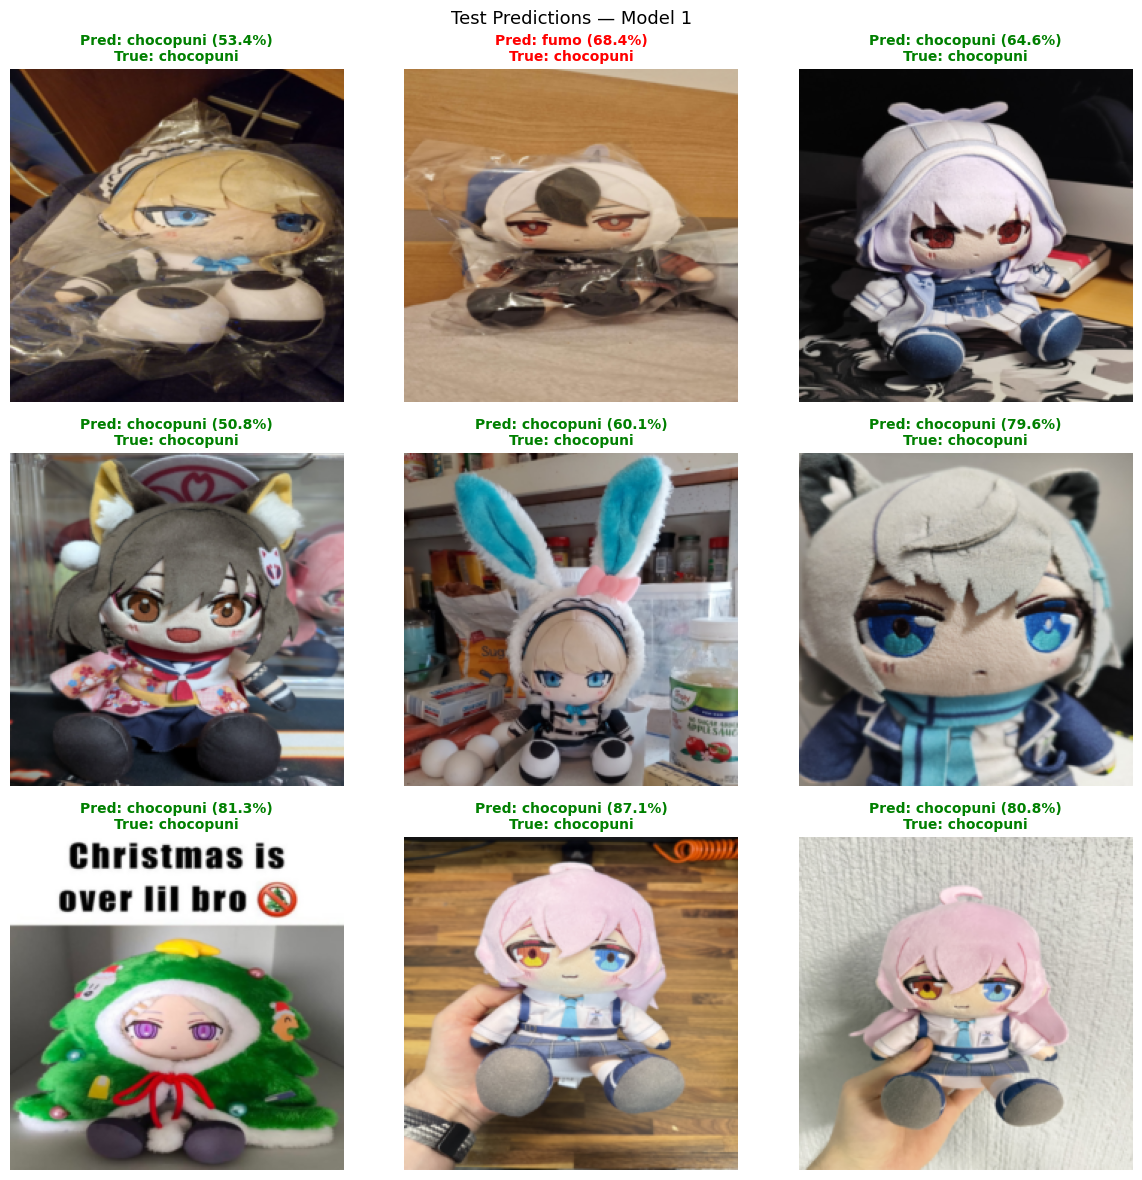

In [9]:
images, labels = next(iter(test_loader))

# Call model directly on the batch tensor — .predict() expects a DataLoader
with torch.no_grad():
    predictions = test_model(images)
predictions = predictions.cpu().numpy()

plt.figure(figsize=(12, 12))
n = min(9, len(images))

for i in range(n):
    pred_idx   = np.argmax(predictions[i])
    confidence = predictions[i][pred_idx]
    true_idx   = labels[i].item()

    pred_label = CLASS_NAMES[pred_idx]
    true_label = CLASS_NAMES[true_idx]

    img_plot = denormalize(images[i]).permute(1, 2, 0).numpy()

    plt.subplot(3, 3, i + 1)
    plt.imshow(img_plot)
    color = "green" if pred_idx == true_idx else "red"
    plt.title(
        f"Pred: {pred_label} ({confidence*100:.1f}%)\nTrue: {true_label}",
        color=color, fontsize=10, fontweight="bold"
    )
    plt.axis("off")

plt.suptitle("Test Predictions — Model 1", fontsize=13)
plt.tight_layout()
plt.show()

## 10. Confusion Matrix

The confusion matrix

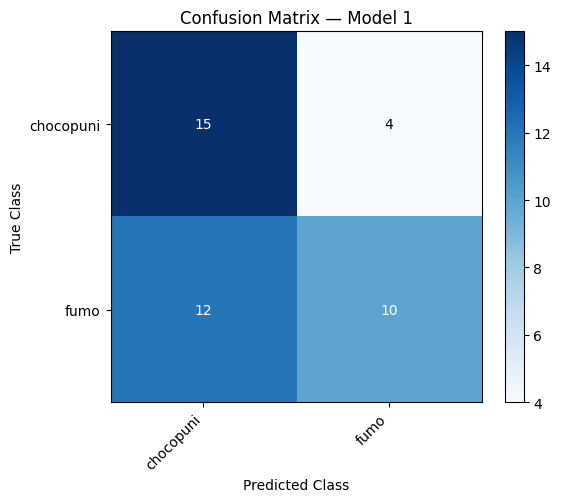

              precision    recall  f1-score   support

   chocopuni       0.56      0.79      0.65        19
        fumo       0.71      0.45      0.56        22

    accuracy                           0.61        41
   macro avg       0.63      0.62      0.60        41
weighted avg       0.64      0.61      0.60        41



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import itertools

all_preds  = []
all_labels = []

for images, labels in test_loader:
    with torch.no_grad():
        outputs = test_model(images)
    preds = np.argmax(outputs.cpu().numpy(), axis=1)
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.set_title("Confusion Matrix — Model 1")

thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, cm[i, j], ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

### Interpretation

Overall test accuracy of **61%** is slightly above random chance (50% baseline
for a balanced two-class problem), which is the expected outcome for a small CNN
trained from scratch without pretrained weights.

- **Chocopuni recall = 0.79** — the model finds most Chocopuni correctly, but with
  low precision (0.56), meaning it over-predicts this class and mislabels many Fumo
  as Chocopuni
- **Fumo precision = 0.71** — when the model does predict Fumo, it is usually right,
  but recall = 0.45 means it misses more than half of actual Fumo images
- The model has developed a **bias toward predicting Chocopuni**: high recall but low
  precision for Chocopuni, and the opposite pattern for Fumo
- Macro avg F1 = 0.60 confirms weak but non-trivial performance on both classes

This result serves as the baseline. Models 2 and 3 are expected to improve
significantly by leveraging ImageNet pretrained features.